# 00_raw_eda · 122630 KODEX 레버리지 (slot 4) — ETF Raw EDA

SSOT: `notebooks/_template/00_etf_raw_eda.ipynb` → `scripts/build_notebooks.py` 로 생성. 이 파일을 직접 고치지 말 것.

In [1]:
TICKER = "122630"
SLOT = 4

In [2]:
import sys, os, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown
warnings.filterwarnings("ignore")
np.random.seed(0)

ROOT = Path.cwd().resolve()
while not (ROOT / "config" / "universe.csv").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("config/universe.csv not found")
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src import eda_utils as eu
from src.style import setup_notebook, banner, kpis
setup_notebook()
LIMITATIONS = [eu.LIMITATION_PRICE]
def cap(sec, st, extra=None):
    display(Markdown(eu.caption(sec, st, extra)))

## 00 Identity / Domain Card

In [3]:
U = eu.read_universe(ROOT)
row = U.loc[U["ticker"] == TICKER].iloc[0].to_dict()
banner(f"{TICKER} · {row.get('name','')}", f"UNIVERSE_STATUS={row.get('universe_status','PROVISIONAL') or 'PROVISIONAL'} — 공식 list 입수 시 교체")
display(pd.DataFrame([row]).T.rename(columns={0: "value"}))
KEYF = ["benchmark", "benchmark_proxy_ticker", "currency_hedge", "replication", "trading_hours_note", "structural_notes", "confidence"]
display(pd.DataFrame({"field": KEYF, "value": [row.get(k, "(missing column)") for k in KEYF]}))
print("price policy:", eu.PRICE_POLICY_UNADJ)

,value
slot,4
ticker,122630
name,KODEX 레버리지
provider_brand,KODEX (삼성자산운용)
listing_date,2010-02
listing_date_source,domain knowledge [ANA]; FDR first row 2014-07-...
data_start,2019-01-02
asset_scope,domestic_equity
category,leveraged_inverse
benchmark,KOSPI 200 (일간 2배)


,field,value
0,benchmark,KOSPI 200 (일간 2배)
1,benchmark_proxy_ticker,069500
2,currency_hedge,n/a (KRW)
3,replication,futures
4,trading_hours_note,KRX same-session
5,structural_notes,"[OBS] Category=3. 일일 리밸런싱 → 일간수익률≈2×지수, 다기간 누적..."
6,confidence,med


price policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


### 00 · 이 ETF 는 무엇인가 (ETF-specific)
- **KODEX 레버리지 (122630)** · domestic_equity / leveraged_inverse · 추종 KOSPI 200 (일간 2배) · 레버리지 2x · 환헤지 n/a (KRW) · 복제 futures.
- 거래시간: KRX same-session.
- 비교 기준 ETF(benchmark proxy): 069500.
- UNIVERSE_STATUS=PROVISIONAL · 수익률은 조정가격 수익률(추정, DEC-3).

### ETF-specific reading (A card @efada2e)
**정체성**

- [OBS] domestic_equity · leveraged_inverse · benchmark KOSPI 200 (일간 2배) · peer_group KOSPI200_geared · leverage 2x · hedge n/a(KRW) · futures(선물+현물 혼합)
- [ANA] 구조적 주의: 하루 단위로 2배를 맞추므로(일일 리밸런싱) 여러 날 누적은 "2×누적"과 달라진다(경로의존).

## 01 Raw Data Audit

In [4]:
raw, PROV = eu.load_raw(eu.raw_path(TICKER))
print("price_policy:", PROV["price_policy"])
display(pd.DataFrame([{k: v for k, v in PROV.items() if k != "duplicate_dates"}]).T.rename(columns={0: "value"}))
display(eu.quality_summary(raw))
OHLC_BAD = eu.ohlc_violations(raw); GAPS = eu.date_gaps(raw, 5)
print("OHLC violations:", len(OHLC_BAD)); display(OHLC_BAD.head(10))
print("date gaps > 5 calendar days:", len(GAPS)); display(GAPS)
x, FLAGS = eu.engineer_basic(raw)
HAS_VOL = FLAGS["has_volume"]
if not HAS_VOL: LIMITATIONS.append("no_volume")
if FLAGS["n_zero_volume_days"] > 0: LIMITATIONS.append("zero_volume_days")
if len(x) < 500: LIMITATIONS.append("short_history")
if PROV["n_duplicate_dates"] > 0: LIMITATIONS.append("duplicate_dates")
START, END, N = x["date"].iloc[0], x["date"].iloc[-1], len(x)
ZERO_VOL_RATIO = FLAGS["n_zero_volume_days"] / N
print("first", START.date(), "last", END.date())

price_policy: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION


,value
source_file,/home/sieg/projects-wsl/hongik_univ_26_2/SA/ET...
rows_raw,1903
n_unparseable_dates,0
was_sorted,True
n_duplicate_dates,0
rows_after,1903
price_policy,FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으...
has_adj_close,False
has_volume,True
n_zero_volume_days,0


,column,dtype,n,missing_n,missing_pct,unique_n
0,date,datetime64[us],1903,0,0.0000,1903
1,open,int64,1903,0,0.0000,1490
2,high,int64,1903,0,0.0000,1499
3,low,int64,1903,0,0.0000,1532
4,close,int64,1903,0,0.0000,1527
5,volume,int64,1903,0,0.0000,1903
6,change,float64,1903,0,0.0000,1888
7,price,int64,1903,0,0.0000,1527


OHLC violations: 0


,date,open,high,low,close


date gaps > 5 calendar days: 9


,date,prev_date,gap_days
0,2019-02-07,2019-02-01,6
1,2020-10-05,2020-09-29,6
2,2021-09-23,2021-09-17,6
3,2022-02-03,2022-01-28,6
4,2023-10-04,2023-09-27,7
5,2024-09-19,2024-09-13,6
6,2025-01-31,2025-01-24,7
7,2025-10-10,2025-10-02,8
8,2026-02-19,2026-02-13,6


first 2019-01-02 last 2026-10-02


In [5]:
extra = [f"가격 정책: {PROV['price_policy']}"]
if not HAS_VOL: extra.append("거래량 컬럼이 없거나 전부 0 → 거래량 기반 분석 생략")
cap("01", {"rows_raw": PROV["rows_raw"], "rows_after": PROV["rows_after"], "n_duplicate_dates": PROV["n_duplicate_dates"],
           "n_unparseable_dates": PROV["n_unparseable_dates"], "was_sorted": PROV["was_sorted"], "ohlc_violations": len(OHLC_BAD),
           "n_gaps_gt5d": len(GAPS), "n_zero_volume_days": FLAGS["n_zero_volume_days"], "zero_vol_ratio": ZERO_VOL_RATIO,
           "first": START.date(), "last": END.date()}, extra)

#### 01 · WHAT WE SEE (raw values)
- `rows_raw` = 1903
- `rows_after` = 1903
- `n_duplicate_dates` = 0
- `n_unparseable_dates` = 0
- `was_sorted` = True
- `ohlc_violations` = 0
- `n_gaps_gt5d` = 9
- `n_zero_volume_days` = 0
- `zero_vol_ratio` = 0
- `first` = 2019-01-02
- `last` = 2026-10-02

#### General note · WHY IT MATTERS
행 수·중복·결측·날짜 공백은 이후 모든 rolling 창과 정렬(merge)의 기준이 된다. 감사되지 않은 행은 전처리 단계에서 조용히 왜곡을 만든다.

#### General note · WHAT WE DO NOT KNOW
- 원천(FDR) 이 휴장일 외의 누락을 어떻게 처리하는지는 이 데이터만으로 확인할 수 없다.
- 가격 정책: FDR Close — 조정가격 수익률(추정): FDR Close 는 분배 소급조정으로 추정(069500/KS200 누적비 1.155 ≈ TR 1.163), O/H/L 조정 일관성 미보장 — KNOWN_LIMITATION

#### General note · NEXT QUESTION
- 감사에서 걸린 행(중복/공백/OHLC 위반)을 전처리에서 제거·보간·flag 중 무엇으로 처리할 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 01 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **OHLC 논리 위반일(ohlc_close_gt_high) 0** — 20종 중 공동 4위(17종 동률)(높은 순), 백분위 85% (universe 중앙값 0).
- **|일간 수익률|>15% 점프일 18** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 18.00배 (universe 중앙값 0).
- **dq_flags 행 수 0** — 20종 중 공동 8위(13종 동률)(높은 순), 백분위 65% (universe 중앙값 0).

- DQ 각주: reports/dq_flags.csv 에 이 ETF 의 flag 없음.

## 02 Whole-History Visual Scan

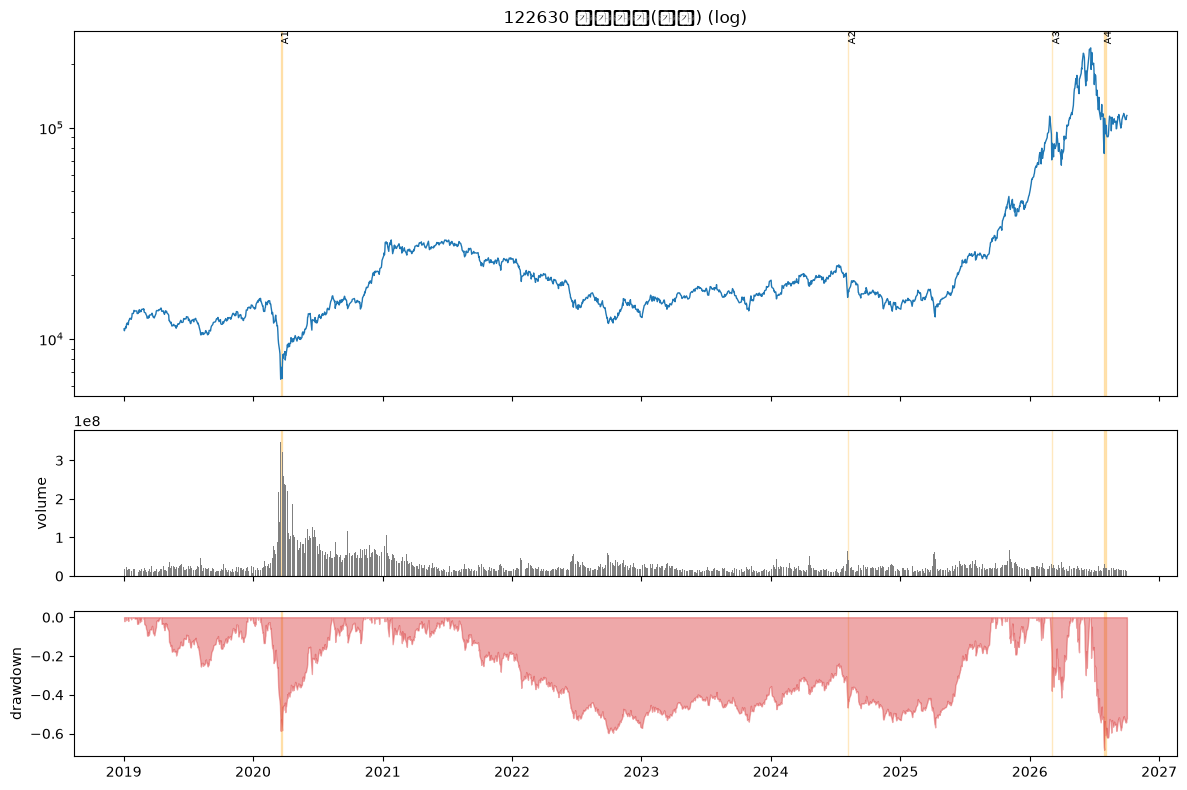

In [6]:
fig, ax = plt.subplots(3, 1, figsize=(12, 8), sharex=True, height_ratios=[3, 1.2, 1.2])
ax[0].plot(x["date"], x["price"], lw=1); ax[0].set_yscale("log"); ax[0].set_title(f"{TICKER} 조정가격(추정) (log)")
ANCH = eu.read_event_anchors(ROOT)
for _, a in ANCH.iterrows():
    s0, s1 = pd.to_datetime(a["start"], errors="coerce"), pd.to_datetime(a["end"] or a["start"], errors="coerce")
    if pd.notna(s0):
        for axx in ax: axx.axvspan(s0, s1 if pd.notna(s1) else s0, color="orange", alpha=.25)
        ax[0].text(s0, ax[0].get_ylim()[1], a.get("anchor_id", ""), fontsize=7, va="top", rotation=90)
if HAS_VOL: ax[1].bar(x["date"], x["volume"], width=1.5, color="gray")
else: ax[1].text(0.5, 0.5, "no volume", transform=ax[1].transAxes, ha="center")
ax[1].set_ylabel("volume")
ax[2].fill_between(x["date"], x["drawdown"], 0, color="tab:red", alpha=.4); ax[2].set_ylabel("drawdown")
plt.tight_layout(); plt.show()

In [7]:
cap("02", {"price_first": x["price"].iloc[0], "price_last": x["price"].iloc[-1],
           "price_min": x["price"].min(), "price_max": x["price"].max(), "min_drawdown": x["drawdown"].min(),
           "volume_median": x["volume"].median() if HAS_VOL else "n/a"})

#### 02 · WHAT WE SEE (raw values)
- `price_first` = 11160
- `price_last` = 114395
- `price_min` = 6450
- `price_max` = 239000
- `min_drawdown` = -0.6837
- `volume_median` = 1.952e+07

#### General note · WHY IT MATTERS
전체 이력의 수준·거래량·낙폭을 한 화면에서 보면 구조 변화(regime)나 이상 구간이 있는지, 정규화 창을 어디서 끊어야 할지 판단할 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 가격 점프가 분배금/분할 때문인지 실제 가격 변동인지 이 데이터만으로 구분할 수 없다.

#### General note · NEXT QUESTION
- 전체 기간을 하나의 정규화 창으로 볼 수 있는가, 아니면 구간을 나눠야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 02 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **기간 누적 가격 변화(2019-01-02→최종일, 조정가격 추정) +925.0%** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 2.31배 (universe 중앙값 +140.3%).

## 03 Return Distribution

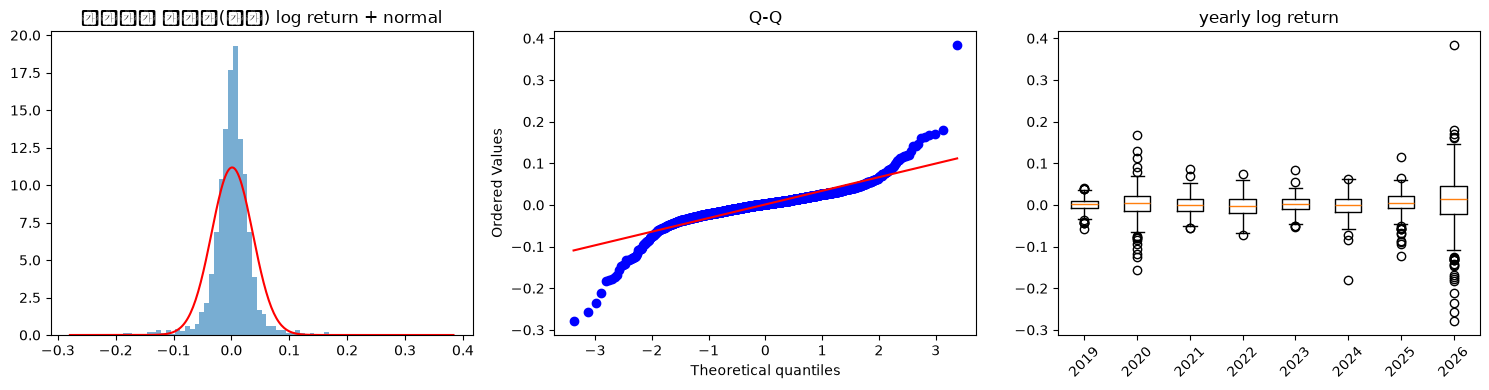

In [8]:
r = x["log_ret"].dropna()
K = {"mean": r.mean(), "std": r.std(), "ann_vol": r.std() * np.sqrt(252), "skew": stats.skew(r),
     "ex_kurt": stats.kurtosis(r), "ex_kurt_trim3": eu.kurt_trim(r, 3), "p01": r.quantile(.01), "p99": r.quantile(.99), "n": len(r)}
kpis([(k, f"{v:.4g}") for k, v in K.items()])
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].hist(r, bins=80, density=True, alpha=.6); g = np.linspace(r.min(), r.max(), 300)
ax[0].plot(g, stats.norm.pdf(g, r.mean(), r.std()), "r-"); ax[0].set_title("조정가격 수익률(추정) log return + normal")
stats.probplot(r, dist="norm", plot=ax[1]); ax[1].set_title("Q-Q")
yr = x.dropna(subset=["log_ret"]).groupby(x["date"].dt.year)["log_ret"]
ax[2].boxplot([v.values for _, v in yr], tick_labels=[str(k) for k, _ in yr]); ax[2].set_title("yearly log return")
ax[2].tick_params(axis="x", rotation=45)
plt.tight_layout(); plt.show()

In [9]:
cap("03", K)

#### 03 · WHAT WE SEE (raw values)
- `mean` = 0.001224
- `std` = 0.03568
- `ann_vol` = 0.5665
- `skew` = -0.325
- `ex_kurt` = 15.87
- `ex_kurt_trim3` = 7.975
- `p01` = -0.1244
- `p99` = 0.1051
- `n` = 1902

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 03b Core stats — full / by year / 2026-07-20~08-10 제외 / DQ 포함 vs 제외

In [10]:
SV, DQ_NOTE = eu.stats_variants(x, ROOT, TICKER)
display(SV); print("DQ:", DQ_NOTE)
if DQ_NOTE != "no_dq_flags": LIMITATIONS.append("dq_flagged_dates")  # 해당일 포함/제외 병기됨
exk = [i for i in SV.index if i.startswith("excl_")][0]
cap("03", {"full_ann_vol": SV.loc["full", "ann_vol"], "excl_window_ann_vol": SV.loc[exk, "ann_vol"],
           "full_ex_kurt": SV.loc["full", "ex_kurt"], "excl_window_ex_kurt": SV.loc[exk, "ex_kurt"],
           "dq_excluded_ex_kurt": SV.loc["dq_excluded", "ex_kurt"], "dq_note": DQ_NOTE,
           "year_ann_vol_min": SV.filter(like="year_", axis=0)["ann_vol"].min(), "year_ann_vol_max": SV.filter(like="year_", axis=0)["ann_vol"].max()})

,n,ann_vol,ex_kurt,ex_kurt_trim3,p01,p99,max_dd
full,"1,902.0000",0.5665,15.8724,7.9751,-0.1244,0.1051,-0.6837
year_2019,245.0000,0.2693,0.4739,0.0289,-0.0439,0.0385,-0.2546
year_2020,248.0000,0.5767,4.1141,2.1925,-0.1125,0.1027,-0.5857
year_2021,248.0000,0.3427,0.9662,0.0134,-0.0494,0.0526,-0.2810
year_2022,246.0000,0.3789,0.1353,-0.3156,-0.0554,0.0506,-0.5065
year_2023,245.0000,0.3092,0.9318,-0.1569,-0.0479,0.0397,-0.2491
year_2024,244.0000,0.4083,9.0663,-0.0321,-0.0663,0.0503,-0.3966
year_2025,242.0000,0.4555,2.7538,1.1230,-0.0880,0.0601,-0.2603
year_2026,184.0000,1.3414,2.6573,0.6812,-0.2384,0.1718,-0.6837
excl_2026-07-20~2026-08-10,"1,886.0000",0.5301,10.0719,6.8255,-0.1104,0.1021,-0.6126


DQ: no_dq_flags


#### 03 · WHAT WE SEE (raw values)
- `full_ann_vol` = 0.5665
- `excl_window_ann_vol` = 0.5301
- `full_ex_kurt` = 15.87
- `excl_window_ex_kurt` = 10.07
- `dq_excluded_ex_kurt` = 15.87
- `dq_note` = no_dq_flags
- `year_ann_vol_min` = 0.2693
- `year_ann_vol_max` = 1.341

#### General note · WHY IT MATTERS
수익률 분포의 꼬리(첨도·왜도·분위수)는 z-score 같은 정규 가정 기반 정규화가 얼마나 맞지 않는지를 직접 보여준다.

#### General note · WHAT WE DO NOT KNOW
- 분포 모양이 기간에 따라 안정적인지는 단일 전체표본 통계로는 알 수 없다.

#### General note · NEXT QUESTION
- 꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 03 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **연환산 변동성 56.6%** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 1.99배 (universe 중앙값 28.4%).
- **초과첨도(full) 15.9** — 20종 중 7위(높은 순), 백분위 70%, 069500 의 0.84배 (universe 중앙값 10.5).
- **초과첨도(상위 |r| 3일 제외) 8.0** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 1.01배 (universe 중앙값 3.9).
- **왜도 -0.33** — 20종 중 14위(높은 순), 백분위 35% (universe 중앙값 -0.11).
- **일간 로그수익률 1% 분위 -12.44%** — 20종 중 1위(낮은(더 극단) 순), 백분위 100%, 069500 의 2.09배 (universe 중앙값 -5.18%).
- **일간 로그수익률 99% 분위 +10.51%** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 1.99배 (universe 중앙값 +5.15%).

- DQ 각주: reports/dq_flags.csv 에 이 ETF 의 flag 없음.

### ETF-specific reading (A card @efada2e)
**평소 움직임**

- [OBS] ann_vol 56.6% (exw 53.0%) · skew −0.33 (exw −0.82) · ex_kurt full 15.9 / trim3 8.0 (exw 10.1 / exw-trim3 6.8) · q01 −12.4% / q99 +10.5% · |r| q95 6.65% q99 14.25% (exw 6.15%/13.44%)
- [OBS] 연도별 ann vol: 2019 26.9% · 2020 57.7% · 2021 34.3% · 2022 37.9% · 2023 30.9% · 2024 40.8% · 2025 45.6% · **2026 134.1%** (매년 069500 의 1.95~2.03배)
- [ANA] vol 이 정확히 약 2배라 구조와 일치. 단 skew 가 069500(+0.16)과 달리 음수 → 하락 꼬리가 상대적으로 더 길다.

## 04 Volatility Dynamics

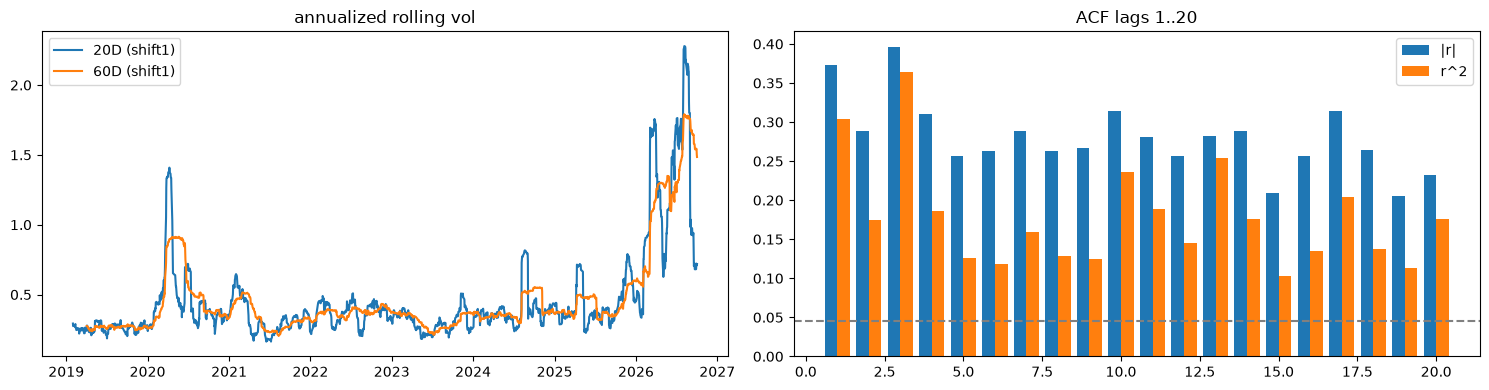

,lag,acf_absret,acf_sqret
0,1,0.3735,0.3039
1,2,0.2887,0.1746
2,3,0.3963,0.3635
3,4,0.3105,0.1867
4,5,0.2568,0.1260
5,6,0.2633,0.1178
6,7,0.2891,0.1595
7,8,0.2636,0.1286
8,9,0.2670,0.1242
9,10,0.3147,0.2365


,lb_stat,lb_pvalue
5,"1,033.9221",0.0000
10,"1,784.8204",0.0000
20,"3,093.2919",0.0000


In [11]:
ACF_ABS = eu.acf(x["abs_ret"], 20); ACF_SQ = eu.acf(x["log_ret"] ** 2, 20)
VOL_OF_VOL = float((x["roll_vol_20"] / x["roll_vol_20"].mean()).std())
from statsmodels.stats.diagnostic import acorr_ljungbox
LB = acorr_ljungbox(x["abs_ret"].dropna(), lags=[5, 10, 20])
fig, ax = plt.subplots(1, 2, figsize=(15, 4))
ax[0].plot(x["date"], x["roll_vol_20"] * np.sqrt(252), label="20D (shift1)")
ax[0].plot(x["date"], x["roll_vol_60"] * np.sqrt(252), label="60D (shift1)"); ax[0].legend(); ax[0].set_title("annualized rolling vol")
lags = np.arange(1, 21)
ax[1].bar(lags - .2, ACF_ABS, .4, label="|r|"); ax[1].bar(lags + .2, ACF_SQ, .4, label="r^2")
ax[1].axhline(1.96 / np.sqrt(len(x)), ls="--", c="gray"); ax[1].legend(); ax[1].set_title("ACF lags 1..20")
plt.tight_layout(); plt.show()
display(pd.DataFrame({"lag": lags, "acf_absret": ACF_ABS, "acf_sqret": ACF_SQ}).head(10)); display(LB)

In [12]:
cap("04", {"acf_absret_lag1": ACF_ABS[0], "acf_absret_lag5": ACF_ABS[4], "acf_sqret_lag1": ACF_SQ[0],
           "vol_of_vol(cv of roll_vol_20)": VOL_OF_VOL, "ljungbox_absret_lag20_p": LB["lb_pvalue"].iloc[-1],
           "roll_vol_20_ann_median": x["roll_vol_20"].median() * np.sqrt(252)})

#### 04 · WHAT WE SEE (raw values)
- `acf_absret_lag1` = 0.3735
- `acf_absret_lag5` = 0.2568
- `acf_sqret_lag1` = 0.3039
- `vol_of_vol(cv of roll_vol_20)` = 0.7491
- `ljungbox_absret_lag20_p` = 0
- `roll_vol_20_ann_median` = 0.3529

#### General note · WHY IT MATTERS
변동성 군집(|r|, r^2 의 자기상관)이 있으면 고정 임계값보다 시간가변 baseline 정규화가 필요하다는 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 표본이 크면 Ljung-Box 는 작은 자기상관도 유의하게 만든다 — 유의성은 크기의 증거가 아니다.

#### General note · NEXT QUESTION
- baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 04 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|r| lag1 자기상관(변동성 군집) 0.373** — 20종 중 6위(높은 순), 백분위 75%, 069500 의 0.98배 (universe 중앙값 0.302).
- **vol-of-vol 0.749** — 20종 중 6위(높은 순), 백분위 75%, 069500 의 0.99배 (universe 중앙값 0.544).

### ETF-specific reading (A card @efada2e)
**변동성 구조**

- [OBS] acf_r1 −0.074 · acf_abs1/5/20 = 0.373/0.257/0.233 · 20D rolling vol median 35.3%, p90/p10 = 76.0%/23.8% = 3.20배 · vol_ratio_hi_lo 5.27
- [OBS] 60D vol 최고 2026-08-05 179.1%, 최저 2021-08-11 20.6%; 상위 5% 구간 2026-04-08~2026-10-02.

## 05 Trading Activity

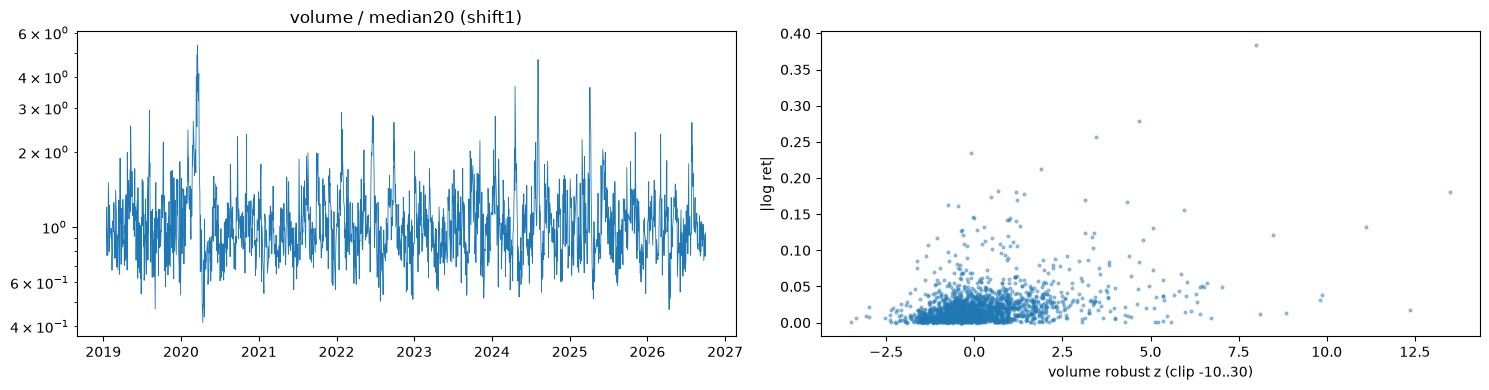

In [13]:
VOLST = {}
if HAS_VOL:
    vz = x["volume_robust_z_20"]
    rho, p = stats.spearmanr(x["abs_ret"], vz, nan_policy="omit")
    ext = x["abs_q95"].fillna(False)
    VOLST = {"spearman_absret_volz": rho, "spearman_p": p, "volz_median_extreme(abs_q95)": vz[ext].median(),
             "volz_median_normal": vz[~ext].median(), "volratio_median_extreme": x["volume_ratio_20"][ext].median(),
             "volratio_median_normal": x["volume_ratio_20"][~ext].median(), "n_mad_zero": FLAGS["n_mad_zero"]}
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(x["date"], x["volume_ratio_20"], lw=.6); ax[0].set_yscale("log"); ax[0].set_title("volume / median20 (shift1)")
    ax[1].scatter(vz.clip(-10, 30), x["abs_ret"], s=4, alpha=.4); ax[1].set_xlabel("volume robust z (clip -10..30)"); ax[1].set_ylabel("|log ret|")
    plt.tight_layout(); plt.show()
else:
    print("SKIP: 거래량 없음 (has_volume=False)")
    VOLST = {"skipped": "no_volume"}

In [14]:
cap("05", VOLST, None if HAS_VOL else ["거래량이 없어 이 절 분석을 생략했다."])

#### 05 · WHAT WE SEE (raw values)
- `spearman_absret_volz` = 0.3416
- `spearman_p` = 1.081e-52
- `volz_median_extreme(abs_q95)` = 0.9541
- `volz_median_normal` = -0.1267
- `volratio_median_extreme` = 1.272
- `volratio_median_normal` = 0.9679
- `n_mad_zero` = 0

#### General note · WHY IT MATTERS
거래량 baseline(shift(1))과 수익률 크기의 관계는 거래량을 극단 후보의 보조 신호로 쓸 수 있는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- 거래량 급증의 원인(설정/환매, LP 호가, 리밸런싱)은 이 데이터에 없다.

#### General note · NEXT QUESTION
- 거래량 robust z 를 극단 후보의 보조 조건으로 쓸 가치가 있는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 05 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **일 거래대금 중앙값(Close×Volume, 억원) 3,814.8** — 20종 중 1위(높은 순), 백분위 100%, 069500 의 1.71배 (universe 중앙값 31.2).
- **일 거래량 중앙값(주) 19,515,876** — 20종 중 2위(높은 순), 백분위 95%, 069500 의 2.72배 (universe 중앙값 169,876).

### ETF-specific reading (A card @efada2e)
**거래활동**

- [OBS] med_volume 19,515,876주(069500 의 2.7배) · zero_vol_days 0 · corr(|r|, Δlog vol) 0.274 · volume ratio ≥2 동반률: |rz|>4 일 35% · |rz|>3 일 25% · **top5 5/5** (전체 기준률 3.3%)
- [ANA] 기초지수 ETF 보다 거래가 많고 |r|–거래량 변화 연동(0.274)도 더 강하다 → 단기 매매 수요가 몰리는 상품.

## 06 Drawdown / Recovery / Persistence

In [15]:
EP = eu.drawdown_episodes(x["price"], x["date"], 5)
i_min = int(x["drawdown"].idxmin()); MAX_DD = float(x["drawdown"].min()); MAX_DD_DATE = x["date"].iloc[i_min].date()
rec = x.index[(x.index > i_min) & (x["drawdown"] >= 0)]
RECOVERY_DAYS = int((x["date"].iloc[rec[0]] - x["date"].iloc[i_min]).days) if len(rec) else None
display(EP)
lp = np.log(x["price"])
fw = {}
for h in (1, 3, 5, 10):
    f = lp.shift(-h) - lp
    fw[h] = {"pos_q95": f[x["pos_q95"]].mean(), "neg_q05": f[x["neg_q05"]].mean(), "all": f.mean()}
FWD = pd.DataFrame(fw).T.rename_axis("h"); display(FWD)
print("※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).")

,peak_date,trough_date,depth,recovery_date,recovery_days
0,2026-06-22,2026-07-30,-0.6837,None,NaN
1,2021-01-25,2022-09-30,-0.5978,2025-09-16,"1,082.0000"
2,2020-01-22,2020-03-19,-0.5857,2020-08-11,145.0000
3,2026-02-26,2026-03-31,-0.4141,2026-04-27,27.0000
4,2026-06-01,2026-06-08,-0.2986,2026-06-18,10.0000


,pos_q95,neg_q05,all
h,,,
1,0.0024,0.0062,0.0012
3,0.0031,0.0060,0.0037
5,0.0137,0.0170,0.0061
10,0.0075,0.0354,0.0120


※ EDA-only: 겹치는 표본, full-sample 분위수(look-ahead).


In [16]:
cap("06", {"max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS if RECOVERY_DAYS is not None else "not recovered",
           "fwd5_after_pos_q95": FWD.loc[5, "pos_q95"], "fwd5_after_neg_q05": FWD.loc[5, "neg_q05"], "fwd5_all": FWD.loc[5, "all"]})

#### 06 · WHAT WE SEE (raw values)
- `max_dd` = -0.6837
- `max_dd_date` = 2026-07-30
- `recovery_days` = not recovered
- `fwd5_after_pos_q95` = 0.0137
- `fwd5_after_neg_q05` = 0.01699
- `fwd5_all` = 0.006054

#### General note · WHY IT MATTERS
낙폭 깊이·회복 기간·극단일 이후 forward return 은 이벤트 창 길이와 사후 관측 구간 설계의 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- forward return 은 겹치는 표본(overlapping)이라 독립 관측 수가 실제보다 적다. 인과가 아니다.

#### General note · NEXT QUESTION
- 극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 06 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **최대 낙폭 -68.4%** — 20종 중 4위(낮은(더 극단) 순), 백분위 85%, 069500 의 1.68배 (universe 중앙값 -47.5%).
- **최대 낙폭 회복일수: 미회복** — 최대 낙폭 저점(2026-07-30) 이후 최종일까지 직전 고점 미회복.

### ETF-specific reading (A card @efada2e)
**언제 이상해지는가**

- [OBS] max_dd −68.4%: peak 2026-06-22 → trough 2026-07-30 (27거래일), **미회복**(trough 후 43거래일, 현재 dd −52.1%). 같은 구간 069500 −40.8%.

## 07 Candidate Extreme Windows

최종 label/threshold 아님. z 후보는 shift(1) baseline, q 후보는 full-sample(look-ahead).

,definition,n_days
0,pos_z2,57
1,neg_z2,74
2,abs_z2,131
3,pos_z2_5,25
4,neg_z2_5,36
5,abs_z2_5,61
6,pos_z3,11
7,neg_z3,22
8,abs_z3,33
9,pos_q95,96


,abs_z2,abs_z2_5,abs_z3,abs_q95
abs_z2,1.0000,0.4656,0.2519,0.2270
abs_z2_5,0.4656,1.0000,0.5410,0.2869
abs_z3,0.2519,0.5410,1.0000,0.2056
abs_q95,0.2270,0.2869,0.2056,1.0000


,date,price,log_ret,ret_z20,roll_vol_20
1379,2024-08-05,15730,-0.1807,-7.2661,0.0249
1740,2026-02-02,67460,-0.1243,-5.4943,0.0226
1539,2025-04-07,13195,-0.1215,-5.0261,0.0242
1618,2025-08-01,23635,-0.0863,-4.8554,0.0178
1378,2024-08-02,18845,-0.0837,-4.2489,0.0197
404,2020-08-20,13960,-0.0798,-3.9305,0.0203
1741,2026-02-03,78000,0.1452,3.9280,0.0370
85,2019-05-09,12210,-0.0588,-3.8789,0.0152
357,2020-06-15,11010,-0.1055,-3.8190,0.0276
1758,2026-03-04,70500,-0.2791,-3.7633,0.0742


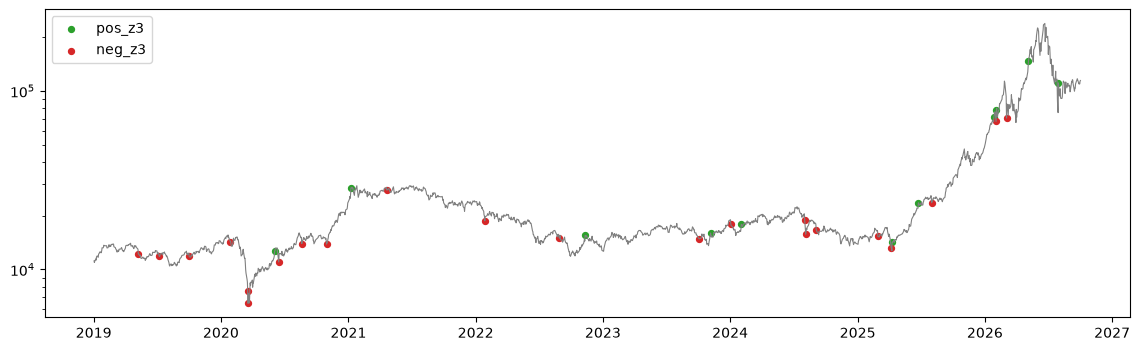

In [17]:
DEFS = [c for c in x.columns if c.startswith(("pos_z", "neg_z", "abs_z")) or c in ("pos_q95", "neg_q05", "abs_q95")]
CNT = pd.DataFrame({"definition": DEFS, "n_days": [int(x[c].sum()) for c in DEFS]}); display(CNT)
absdefs = ["abs_z2", "abs_z2_5", "abs_z3", "abs_q95"]
JAC = pd.DataFrame([[eu.jaccard(x[a], x[b]) for b in absdefs] for a in absdefs], index=absdefs, columns=absdefs); display(JAC)
TOP = x.loc[x["ret_z20"].abs().nlargest(10).index, ["date", "price", "log_ret", "ret_z20", "roll_vol_20"]]; display(TOP)
fig, ax = plt.subplots(figsize=(14, 4)); ax.plot(x["date"], x["price"], lw=.8, c="gray"); ax.set_yscale("log")
ax.scatter(x["date"][x["pos_z3"]], x["price"][x["pos_z3"]], c="tab:green", s=18, label="pos_z3")
ax.scatter(x["date"][x["neg_z3"]], x["price"][x["neg_z3"]], c="tab:red", s=18, label="neg_z3"); ax.legend(); plt.show()
N_POS3, N_NEG3, N_ABS3 = int(x["pos_z3"].sum()), int(x["neg_z3"].sum()), int(x["abs_z3"].sum())

### 07b 정의별 극단일 표 (① abs% q95 ② shift(1) robust z w60 k3 ③ percentile q01/q99)

In [18]:
XDEF, XSC = eu.extreme_definitions(x)
for nm, msk in XDEF.items():
    t = x.loc[msk, ["date", "ret_1d", "log_ret"]].assign(score=XSC[nm][msk])
    print(f"[{nm}] n_days={int(msk.sum())}"); display(t.nlargest(10, "score"))
ks = list(XDEF)
JAC3 = {f"{ks[i]}~{ks[j]}": eu.jaccard(XDEF[ks[i]], XDEF[ks[j]]) for i in range(3) for j in range(i + 1, 3)}
print("Jaccard: " + " | ".join(f"{k}={v:.3f}" for k, v in JAC3.items()))

[abs_pct_q95] n_days=96


,date,ret_1d,log_ret,score
1860,2026-07-31,0.4676,0.3836,0.4676
1758,2026-03-04,-0.2435,-0.2791,0.2435
1857,2026-07-28,-0.2259,-0.2561,0.2259
1833,2026-06-23,-0.2092,-0.2348,0.2092
1759,2026-03-05,0.1984,0.1810,0.1984
1847,2026-07-13,-0.1911,-0.2121,0.1911
1778,2026-04-01,0.1852,0.1699,0.1852
302,2020-03-24,0.1818,0.1671,0.1818
1812,2026-05-21,0.1762,0.1623,0.1762
1823,2026-06-09,0.1753,0.1615,0.1753


[robust_z_shift1_w60_k3] n_days=50


,date,ret_1d,log_ret,score
1758,2026-03-04,-0.2435,-0.2791,9.3908
1379,2024-08-05,-0.1653,-0.1807,7.7619
1757,2026-03-03,-0.1625,-0.1774,6.1610
85,2019-05-09,-0.0571,-0.0588,5.8878
1539,2025-04-07,-0.1144,-0.1215,5.7408
299,2020-03-19,-0.1440,-0.1555,5.6831
302,2020-03-24,0.1818,0.1671,5.6251
1618,2025-08-01,-0.0827,-0.0863,5.3552
1542,2025-04-10,0.1215,0.1147,5.2724
1740,2026-02-02,-0.1168,-0.1243,5.1809


[pctile_q01_q99] n_days=40


,date,ret_1d,log_ret,score
1860,2026-07-31,0.4676,0.3836,0.4676
1758,2026-03-04,-0.2435,-0.2791,0.2435
1857,2026-07-28,-0.2259,-0.2561,0.2259
1833,2026-06-23,-0.2092,-0.2348,0.2092
1759,2026-03-05,0.1984,0.1810,0.1984
1847,2026-07-13,-0.1911,-0.2121,0.1911
1778,2026-04-01,0.1852,0.1699,0.1852
302,2020-03-24,0.1818,0.1671,0.1818
1812,2026-05-21,0.1762,0.1623,0.1762
1823,2026-06-09,0.1753,0.1615,0.1753


Jaccard: abs_pct_q95~robust_z_shift1_w60_k3=0.339 | abs_pct_q95~pctile_q01_q99=0.417 | robust_z_shift1_w60_k3~pctile_q01_q99=0.304


In [19]:
cap("07", {"n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3, "n_abs_z2": int(x["abs_z2"].sum()),
           "n_abs_q95": int(x["abs_q95"].sum()), "jaccard_abs_z3_vs_abs_q95": JAC.loc["abs_z3", "abs_q95"],
           "jaccard_abs_z2_vs_abs_z3": JAC.loc["abs_z2", "abs_z3"], **{f"n_{k}": int(v.sum()) for k, v in XDEF.items()}, **{f"jac_{k}": v for k, v in JAC3.items()}, "max_abs_ret_z20": x["ret_z20"].abs().max()})

#### 07 · WHAT WE SEE (raw values)
- `n_pos_z3` = 11
- `n_neg_z3` = 22
- `n_abs_z3` = 33
- `n_abs_z2` = 131
- `n_abs_q95` = 96
- `jaccard_abs_z3_vs_abs_q95` = 0.2056
- `jaccard_abs_z2_vs_abs_z3` = 0.2519
- `n_abs_pct_q95` = 96
- `n_robust_z_shift1_w60_k3` = 50
- `n_pctile_q01_q99` = 40
- `jac_abs_pct_q95~robust_z_shift1_w60_k3` = 0.3394
- `jac_abs_pct_q95~pctile_q01_q99` = 0.4167
- `jac_robust_z_shift1_w60_k3~pctile_q01_q99` = 0.3043
- `max_abs_ret_z20` = 7.266

#### General note · WHY IT MATTERS
후보 정의마다 선택되는 날이 얼마나 겹치는지는 극단 정의가 정의 선택에 얼마나 민감한지를 보여준다 (최종 정의는 여기서 정하지 않는다).

#### General note · WHAT WE DO NOT KNOW
- q95/q05 후보는 전체표본 분위수(look-ahead) 이므로 실시간 탐지에는 쓸 수 없다.

#### General note · NEXT QUESTION
- 후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 07 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **|z|≥3 후보일(shift(1) 20D vol 기준) 33** — 20종 중 공동 11위(4종 동률)(높은 순), 백분위 50%, 069500 의 1.00배 (universe 중앙값 34).
- **z≥+3 후보일 11** — 20종 중 16위(높은 순), 백분위 25%, 069500 의 0.92배 (universe 중앙값 14).
- **z≤−3 후보일 22** — 20종 중 2위(높은 순), 백분위 95%, 069500 의 1.05배 (universe 중앙값 19).

- DQ 각주: reports/dq_flags.csv 에 이 ETF 의 flag 없음.

### ETF-specific reading (A card @efada2e)
**언제 이상해지는가**

- [OBS] 상위 |robust-z| 5일: 2026-03-04 −27.9% (rz −11.7, universe median −11.5%, 같은부호 |rz|>2 12개, fwd5 +17.5%) · 2020-03-24 +16.7% (rz +9.7, median +6.6%, 15개) · 2020-03-19 −15.6% (rz −9.4, median −8.0%, 14개) · 2026-07-31 **+38.4%** (rz +9.4, median +3.0%, 10개, fwd5 −20.2%) · 2024-08-05 −18.1% (rz −8.6, median −6.8%, 14개)
- [ANA] 5일 모두 공통 충격(DEC-5 anchor). 극단일 |rz|>4 52일(exw 49), |rz|>3 80일 — 069500 과 거의 같은 수 → 2배 상품이지만 "자기 기준 대비" 극단일 빈도는 같다(스케일만 다름).

## 08 Benchmark / Peer Relationship

benchmark (index name): KOSPI 200 (일간 2배) | proxy ticker: 069500


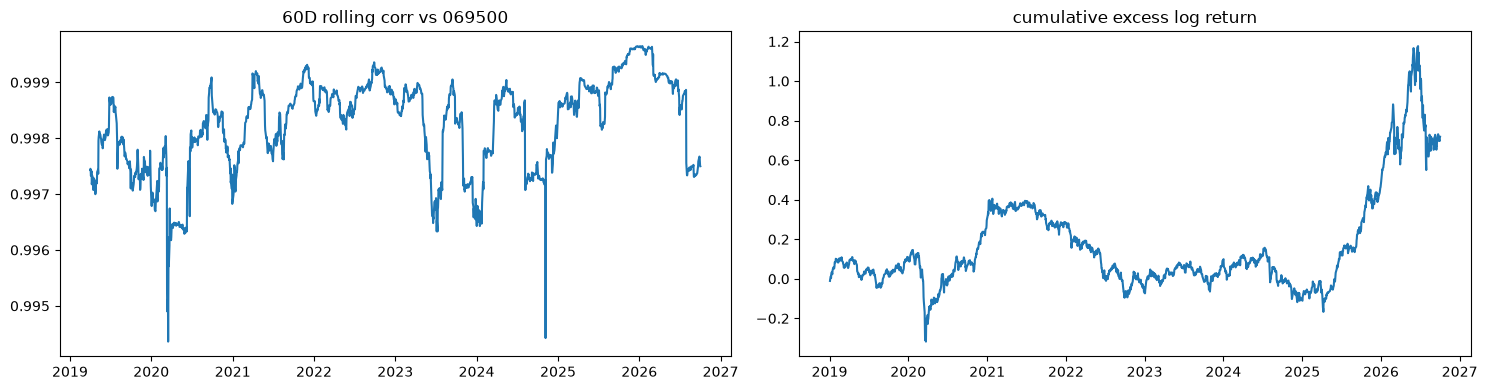

,122630,114800
122630,1.0000,-0.9923
114800,-0.9923,1.0000


In [20]:
BETA = CORR = None; BST = {}
bm = row.get("benchmark_proxy_ticker", "")
print("benchmark (index name):", row.get("benchmark", ""), "| proxy ticker:", bm or "(none)")
if bm and bm != TICKER and eu.raw_path(bm).exists():
    b, _ = eu.load_raw(eu.raw_path(bm)); b, _ = eu.engineer_basic(b)
    m = x[["date", "log_ret"]].merge(b[["date", "log_ret"]], on="date", how="outer", suffixes=("", "_bm"), indicator=True)
    n_unm = int((m["_merge"] != "both").sum()); mm = m[m["_merge"] == "both"].dropna(subset=["log_ret", "log_ret_bm"]).sort_values("date")
    BETA = float(np.cov(mm["log_ret"], mm["log_ret_bm"])[0, 1] / mm["log_ret_bm"].var()); CORR = float(mm["log_ret"].corr(mm["log_ret_bm"]))
    rc = mm["log_ret"].rolling(60).corr(mm["log_ret_bm"])
    fig, ax = plt.subplots(1, 2, figsize=(15, 4))
    ax[0].plot(mm["date"], rc); ax[0].set_title(f"60D rolling corr vs {bm}")
    ax[1].plot(mm["date"], (mm["log_ret"] - mm["log_ret_bm"]).cumsum()); ax[1].set_title("cumulative excess log return")
    plt.tight_layout(); plt.show()
    BST = {"benchmark": bm, "n_unmatched_dates": n_unm, "n_matched": len(mm), "beta": BETA, "corr": CORR, "rolling_corr60_min": rc.min()}
else:
    reason = "benchmark_proxy_ticker 미지정" if not bm else ("self" if bm == TICKER else "benchmark raw 없음")
    print("SKIP benchmark:", reason); BST = {"benchmark_skip": reason}
    if bm and bm != TICKER: LIMITATIONS.append("benchmark_missing")  # proxy 미지정(기준 자체·비주식)은 설계상 정상
pg = row.get("peer_group", "")
peers = [t for t in U.loc[(U["peer_group"] == pg) & (U["ticker"] != TICKER), "ticker"] if pg and eu.raw_path(t).exists()]
if peers:
    rets = {TICKER: x.set_index("date")["log_ret"]}
    for t in peers:
        d, _ = eu.load_raw(eu.raw_path(t)); d, _ = eu.engineer_basic(d); rets[t] = d.set_index("date")["log_ret"]
    PC = pd.DataFrame(rets).corr(); display(PC); BST["n_peers"] = len(peers); BST["peer_corr_mean"] = PC[TICKER].drop(TICKER).mean()
else:
    print("peer 없음 (peer_group=", pg, ")")

In [21]:
cap("08", BST)

#### 08 · WHAT WE SEE (raw values)
- `benchmark` = 069500
- `n_unmatched_dates` = 0
- `n_matched` = 1902
- `beta` = 1.986
- `corr` = 0.9978
- `rolling_corr60_min` = 0.9944
- `n_peers` = 1
- `peer_corr_mean` = -0.9923

#### General note · WHY IT MATTERS
벤치마크·peer 와의 동조성은 개별 ETF 신호와 시장 공통 신호를 분리(초과수익 정규화)해야 하는지에 대한 근거가 된다.

#### General note · WHAT WE DO NOT KNOW
- benchmark 는 universe 내 대리 ticker 이며 공식 추종지수 자체가 아닐 수 있다.

#### General note · NEXT QUESTION
- 극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 08 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **benchmark proxy 와 상관 0.998** — 17종 중 3위(높은 순), 백분위 75%, 069500 의 1.00배 (universe 중앙값 0.655). [proxy 069500 기준 — ETF 마다 비교 대상이 다르므로 순위는 참고용]
- **benchmark proxy 대비 beta 1.99** — 17종 중 1위(높은 순), 백분위 85%, 069500 의 1.98배 (universe 중앙값 0.74). [proxy 069500 기준 — ETF 마다 비교 대상이 다르므로 순위는 참고용]

### ETF-specific reading (A card @efada2e)
**peer 와 다른 점**

- [OBS] Spearman: 069500 0.998 · 102110 0.997 · 091230 0.777 / 114800 −0.996 · 261240 −0.520
- [OBS] vs 069500 일간 로그수익률 기울기: OLS **1.986**, Huber 2.002, R² 0.996, 잔차 std 23bp (exw OLS 2.003, 잔차 20bp); 단순수익률 OLS 1.984. 연도별 1.954(2024)~2.022(2019)
- [OBS] 누적: 122630 +925.0% (gross 10.25배) vs 2×069500 누적 +799.4% (8.99배) vs 069500 단순수익률 일간 2배 복리(이상적) 13.52배
- [OBS] 연도별: 2025 069500 +94.2% → 122630 +243.4%(2.58배); 2021 +3.0% → +1.3%(0.43배)
- [ANA] **"경로의존 decay" 기대와 반대로 전체 기간에서는 2×누적보다 앞섰다** — 2025~26 처럼 한 방향 추세가 강하면 일간 복리가 이득. 반대로 2021(횡보)에는 decay 가 보인다. 이상적 2배 복리(13.52배) 대비 24% 부족은 보수·선물 비용 + 069500 이 분배 조정 가격(TR 근사, DEC-3)이라 기준 차이가 섞인 결과일 수 있다.

## 09 Multivariate Structure (diagnostic)

,pc,explained_ratio
0,PC1,0.5709
1,PC2,0.1881
2,PC3,0.1077
3,PC4,0.0633


pc,PC1,PC2,PC3,PC4
log_ret,-0.0659,0.4356,0.8520,0.1268
abs_ret,0.3766,-0.2976,0.4025,-0.6361
roll_vol_20,0.7158,0.5861,-0.1973,0.1973
drawdown,-0.0263,-0.0006,0.0632,-0.0775
range_pct,0.5728,-0.3938,0.0314,0.0391
volume_robust_z_20,0.1127,-0.4724,0.2612,0.7299


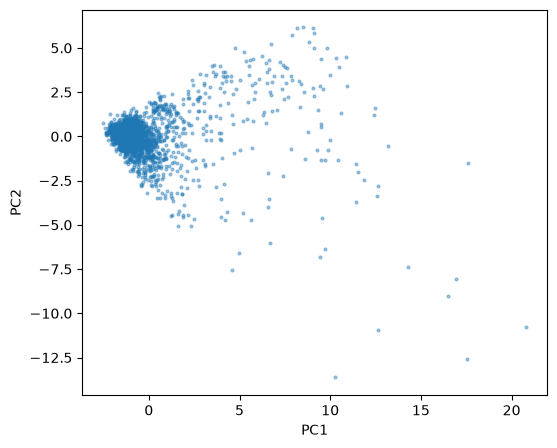

In [22]:
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
feats = ["log_ret", "abs_ret", "roll_vol_20", "drawdown"] + (["range_pct"] if "range_pct" in x else []) + (["volume_robust_z_20"] if HAS_VOL else [])
F = x[feats].replace([np.inf, -np.inf], np.nan).dropna()
Z = RobustScaler().fit_transform(F); pca = PCA(n_components=min(len(feats), 4), random_state=0).fit(Z)
EVR = pd.DataFrame({"pc": [f"PC{i+1}" for i in range(pca.n_components_)], "explained_ratio": pca.explained_variance_ratio_}); display(EVR)
LOAD = pd.DataFrame(pca.components_.T, index=feats, columns=EVR["pc"]); display(LOAD)
S = pca.transform(Z); plt.figure(figsize=(6, 5)); plt.scatter(S[:, 0], S[:, 1], s=4, alpha=.4); plt.xlabel("PC1"); plt.ylabel("PC2"); plt.show()
PC1 = float(pca.explained_variance_ratio_[0])

In [23]:
cap("09", {"n_rows_used": len(F), "features": ", ".join(feats), "pc1_ratio": PC1, "pc2_ratio": float(pca.explained_variance_ratio_[1]),
           "pc1_top_loading": LOAD["PC1"].abs().idxmax()})

#### 09 · WHAT WE SEE (raw values)
- `n_rows_used` = 1882
- `features` = log_ret, abs_ret, roll_vol_20, drawdown, range_pct, volume_robust_z_20
- `pc1_ratio` = 0.5709
- `pc2_ratio` = 0.1881
- `pc1_top_loading` = roll_vol_20

#### General note · WHY IT MATTERS
여러 feature 가 소수의 축으로 요약되는지는 다변량 정규화·차원 축소가 필요한지에 대한 진단이다.

#### General note · WHAT WE DO NOT KNOW
- PCA 는 선형·전체표본 진단이며, 축의 의미를 확정하지 않는다.

#### General note · NEXT QUESTION
- PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?

> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조


### 09 · WHAT WE SEE — 이 ETF (universe 20종 비교, B 계산)
- **PCA PC1 설명비율 57.1%** — 20종 중 5위(높은 순), 백분위 80%, 069500 의 1.05배 (universe 중앙값 50.2%).

## 10 Questions Discovered (SEED only — ACCEPTED/REJECTED 금지)

In [24]:
Q = []
def seed(cond, scope, stmt, ev):
    if cond: Q.append({"id": f"{TICKER}-Q{len(Q)+1:02d}", "scope": scope, "statement": stmt, "status": "SEED", "evidence": ev})
seed(K["ex_kurt"] > 5 and K["ex_kurt_trim3"] > 5, "distribution", "꼬리가 두꺼워 정규 가정 z 정규화가 부적합할 수 있다", f"ex_kurt={K['ex_kurt']:.2f}, trim3={K['ex_kurt_trim3']:.2f}")
seed(ZERO_VOL_RATIO > .01, "volume", "거래량 0 일이 많아 거래량 baseline 이 불안정할 수 있다", f"zero_vol_ratio={ZERO_VOL_RATIO:.3f}")
seed(MAX_DD < -.30, "drawdown", "깊은 낙폭 구간이 정규화 창을 지배할 수 있다", f"max_dd={MAX_DD:.3f}")
seed(abs(ACF_ABS[0]) > .2, "volatility", "변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다", f"acf_absret_lag1={ACF_ABS[0]:.3f}")
seed(not HAS_VOL, "volume", "거래량 부재 — 거래량 기반 후보 정의 불가", "has_volume=False")
seed(CORR is not None and CORR > .9, "benchmark", "benchmark 와 거의 동조 — 초과수익 기준 후보 정의 검토", f"corr={CORR}")
QT = pd.DataFrame(Q, columns=["id", "scope", "statement", "status", "evidence"]); display(QT)

,id,scope,statement,status,evidence
0,122630-Q01,distribution,꼬리가 두꺼워 정규 가정 z 정규화가 부적합할 수 있다,SEED,"ex_kurt=15.87, trim3=7.98"
1,122630-Q02,drawdown,깊은 낙폭 구간이 정규화 창을 지배할 수 있다,SEED,max_dd=-0.684
2,122630-Q03,volatility,변동성 군집이 강해 시간가변 baseline 이 필요할 수 있다,SEED,acf_absret_lag1=0.373
3,122630-Q04,benchmark,benchmark 와 거의 동조 — 초과수익 기준 후보 정의 검토,SEED,corr=0.9978427458428528


## 11 Observation → Implication → Next Question

In [25]:
SUM = pd.DataFrame([
  ("03", "ann_vol / ex_kurt / ex_kurt_trim3", f"{K['ann_vol']:.3f} / {K['ex_kurt']:.2f} / {K['ex_kurt_trim3']:.2f}", eu.NEXT_Q["03"]),
  ("04", "acf_absret_lag1", f"{ACF_ABS[0]:.3f}", eu.NEXT_Q["04"]),
  ("06", "max_dd (date)", f"{MAX_DD:.3f} ({MAX_DD_DATE})", eu.NEXT_Q["06"]),
  ("07", "n_abs_z3 / n_abs_q95", f"{N_ABS3} / {int(x['abs_q95'].sum())}", eu.NEXT_Q["07"]),
  ("08", "corr / beta vs benchmark", f"{CORR} / {BETA}", eu.NEXT_Q["08"]),
  ("09", "pc1_ratio", f"{PC1:.3f}", eu.NEXT_Q["09"]),
], columns=["section", "observation", "number", "next_question"]); display(SUM)
display(Markdown(eu.PLACEHOLDER))

,section,observation,number,next_question
0,03,ann_vol / ex_kurt / ex_kurt_trim3,0.566 / 15.87 / 7.98,꼬리 두께를 감안할 때 z-score 대신 robust/분위수 기반 정규화가 필요한가?
1,04,acf_absret_lag1,0.373,baseline 창 길이(20 vs 60)를 무엇으로 고를 것인가?
2,06,max_dd (date),-0.684 (2026-07-30),극단일 이후 며칠까지를 이벤트 창으로 볼 것인가?
3,07,n_abs_z3 / n_abs_q95,33 / 96,후보 정의 간 불일치가 큰 날들은 어떤 공통 특성을 갖는가?
4,08,corr / beta vs benchmark,0.9978427458428528 / 1.986003034403531,극단 후보를 원수익률이 아니라 benchmark 초과수익으로 정의해야 하는가?
5,09,pc1_ratio,0.571,"PC1 이 주로 변동성 축인가, 방향 축인가 — 이것이 ETF 간에 일관적인가?"


> ETF 고유 해석은 바로 아래 'ETF-specific reading (A card)' 블록 참조

### ETF-specific reading (A card @efada2e)
**WHAT WE SEE / WHY IT MATTERS / WHAT WE DO NOT KNOW / NEXT QUESTION**

- WHAT WE SEE [OBS]: 하루 단위로는 거의 정확히 2배(기울기 1.99)로 움직인다. 하지만 7.75년 누적은 "지수 누적×2"가 아니라 그보다 컸고, 2026 여름엔 한 달 만에 −68% 를 겪었다.
- WHY IT MATTERS [ANA]: 레버리지 ETF 는 "하루 2배"이지 "기간 2배"가 아니다. 상승 추세에선 더 벌고 횡보·급등락장에선 덜 번다 — 보유 기간이 길수록 결과가 경로에 달려 있다.
- WHAT WE DO NOT KNOW [PROJ]: 이상적 2배 복리 대비 부족분(13.52→10.25배) 중 비용·선물 basis·기준(TR vs 가격지수) 차이가 각각 얼마인지.
- NEXT QUESTION [PROJ]: 126일 창마다 (실제 누적 − 2×지수 누적)을 계산하면, 그 창의 변동성이 클수록 값이 더 음수가 되는가?

**Hypothesis candidates**

- HC-122630-1 | OBSERVED | 122630 의 일간 수익률은 069500 의 약 2배다 | OLS 1.986 / Huber 2.002 / R² 0.996 / exw 2.003; 연도별 1.95~2.02; logret.parquet
- HC-122630-2 | TESTABLE | 레버리지 누적 괴리(실제 − 2×지수 누적)는 같은 기간 변동성이 높을수록, 추세가 약할수록 음수가 된다 | 2025 2.58배(강추세) vs 2021 0.43배(횡보); 전체 10.25배 vs 2×누적 8.99배 | RQ: 126일 rolling 괴리가 rolling 분산과 음의 관계인가? H0: 괴리와 rolling 분산 상관 = 0 H1: 상관 < 0

---
<sub>[DEC-7] kurtosis 정의 = excess · log return · Fisher · bias=True. canonical: reports/universe_profile.csv (claude-b a4c17fe) ex_kurt **15.87**, ex_kurt_trim3 **7.98**. 본문 수치와 소수점 차이가 있으면 canonical 을 따른다 (A worker 재계산 값: 정의·trim 대상 차이).</sub>

## 12 Profile Export

In [26]:
PROFILE = {"slot": SLOT, "ticker": TICKER, "name": row.get("name"), "asset_scope": row.get("asset_scope"), "category": row.get("category"),
  "peer_group": row.get("peer_group"), "leverage_inverse": row.get("leverage_inverse"), "start": START, "end": END, "n_obs": N,
  "ann_vol": K["ann_vol"], "mean_ret": K["mean"], "skew": K["skew"], "ex_kurt": K["ex_kurt"], "ex_kurt_trim3": K["ex_kurt_trim3"], "p01": K["p01"], "p99": K["p99"],
  "max_dd": MAX_DD, "max_dd_date": MAX_DD_DATE, "recovery_days": RECOVERY_DAYS, "zero_vol_ratio": ZERO_VOL_RATIO, "vol_of_vol": VOL_OF_VOL,
  "acf_absret_lag1": ACF_ABS[0], "acf_sqret_lag1": ACF_SQ[0], "n_pos_z3": N_POS3, "n_neg_z3": N_NEG3, "n_abs_z3": N_ABS3,
  "beta_vs_benchmark": BETA, "corr_vs_benchmark": CORR, "pca_pc1_ratio": PC1, "price_policy": PROV["price_policy"],
  "has_volume": HAS_VOL, "rows_raw": PROV["rows_raw"], "n_duplicate_dates": PROV["n_duplicate_dates"],
  "run_limitations": sorted(set(LIMITATIONS))}
out = eu.save_profile(PROFILE, ROOT / "data" / "interim" / "profiles" / f"{TICKER}.json")
print("saved", out); PROFILE

saved /home/sieg/projects-wsl/hongik_univ_26_2/SA/.worktrees/SA_ETF/b/data/interim/profiles/122630.json


{'slot': 4,
 'ticker': '122630',
 'name': 'KODEX 레버리지',
 'asset_scope': 'domestic_equity',
 'category': 'leveraged_inverse',
 'peer_group': 'KOSPI200_geared',
 'leverage_inverse': '2x',
 'start': Timestamp('2019-01-02 00:00:00'),
 'end': Timestamp('2026-10-02 00:00:00'),
 'n_obs': 1903,
 'ann_vol': np.float64(0.5664680537155712),
 'mean_ret': np.float64(0.0012236179888242265),
 'skew': np.float64(-0.3250394521504952),
 'ex_kurt': np.float64(15.87237761517352),
 'ex_kurt_trim3': 7.975122917832186,
 'p01': np.float64(-0.12443591980550052),
 'p99': np.float64(0.10510661003110822),
 'max_dd': -0.6837029288702929,
 'max_dd_date': datetime.date(2026, 7, 30),
 'recovery_days': None,
 'zero_vol_ratio': 0.0,
 'vol_of_vol': 0.7490531922126308,
 'acf_absret_lag1': 0.37345006084894944,
 'acf_sqret_lag1': 0.3039114564609404,
 'n_pos_z3': 11,
 'n_neg_z3': 22,
 'n_abs_z3': 33,
 'beta_vs_benchmark': 1.986003034403531,
 'corr_vs_benchmark': 0.9978427458428528,
 'pca_pc1_ratio': 0.5709265603850279,
 'pr